In [1]:
%pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
print("I'm running from:", os.getcwd())
print("Files here:", os.listdir())
print("Inside data/ (if it exists):", os.listdir("data") if os.path.exists("data") else "no data folder")

I'm running from: c:\Users\hp\Documents\customer-churn-prediction
Files here: ['app.py', 'churn_drivers.png', 'churn_eda.ipynb', 'churn_model.pkl', 'data', 'final_model_comaparison.png', 'final_model_comparison.png', 'LR coef.png', 'model_comparison.png', 'requirements.txt', 'scaler.pkl', 'SHAP.png', 'SHAP2.png', 'SHAP3.png', 'shap_summary.png', 'venv', '__pycache__']
Inside data/ (if it exists): ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

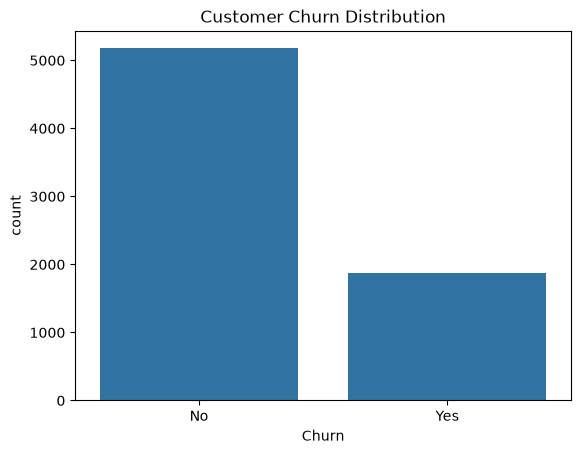

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


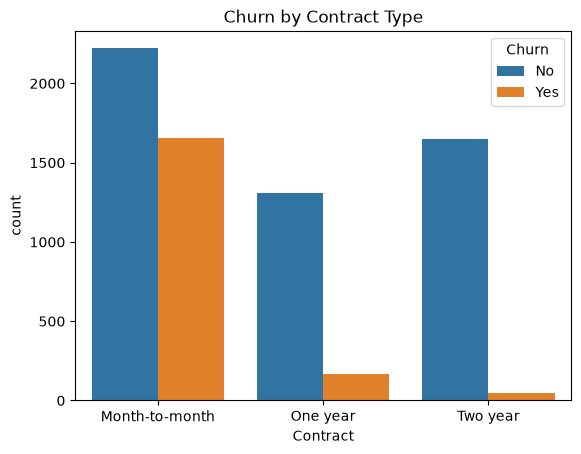

In [10]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

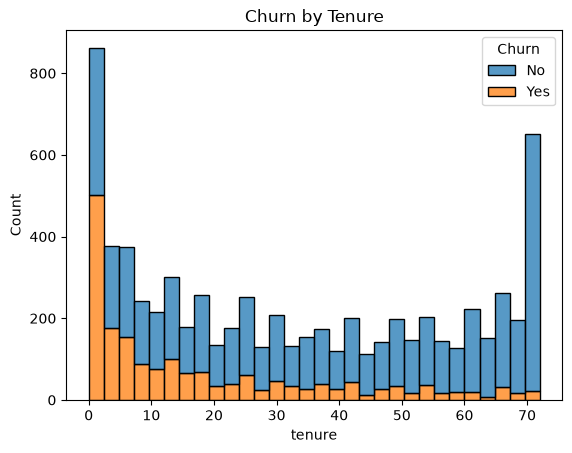

In [11]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()

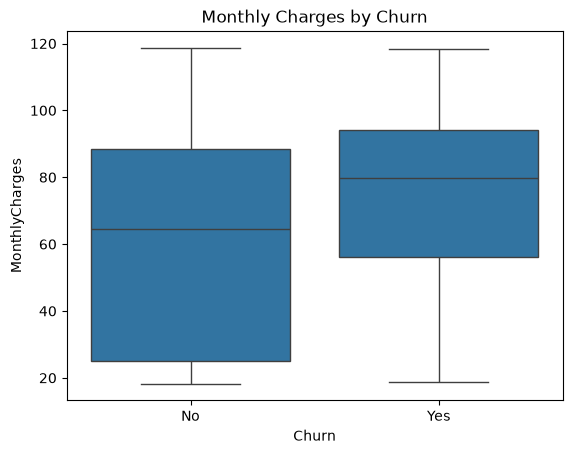

In [12]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

In [13]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [16]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum())

float64
0


In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [19]:
df = df.drop('customerID', axis=1)

In [20]:
df.shape

(7043, 20)

In [21]:
binary_map = {'Yes': 1, 'No': 0}

df['Partner'] = df['Partner'].map(binary_map)
df['Dependents'] = df['Dependents'].map(binary_map)
df['PhoneService'] = df['PhoneService'].map(binary_map)
df['PaperlessBilling'] = df['PaperlessBilling'].map(binary_map)
df['Churn'] = df['Churn'].map(binary_map)

df['gender'] = df['gender'].map({'Female': 0, 'Male' : 1})

In [22]:
df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender']].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,0,0,1,0,0
1,0,0,1,0,0,1
2,0,0,1,1,1,1
3,0,0,0,0,0,1
4,0,0,1,1,1,0


In [23]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.shape
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [25]:
df.shape
df.dtypes.value_counts()

bool       21
int64       8
float64     2
Name: count, dtype: int64

In [26]:
plt.figure(figsize=(12,8))
correlation = df.corr()['Churn'].sort_values(ascending=False)
print(correlation)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


<Figure size 1200x800 with 0 Axes>

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [28]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [30]:
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [31]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

c:\Users\hp\Documents\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lr = LogisticRegression(max_iter=1000)
Lr.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
y_pred = Lr.predict(X_test_scaled)

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[925 110]
 [162 212]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [36]:
Lr_balanced = LogisticRegression(max_iter = 1000, class_weight='balanced')

Lr_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = Lr_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [37]:
y_probs = Lr_balanced.predict_proba(X_test_scaled)[:, 1]
y_probs[:10]    

array([0.11837823, 0.85164028, 0.14131508, 0.66493518, 0.06142382,
       0.80535184, 0.69950956, 0.2938187 , 0.00883709, 0.65216157])

In [38]:
threshold = 0.3
y_pred_threshold = (y_probs >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.95      0.55      0.70      1035
           1       0.43      0.93      0.59       374

    accuracy                           0.65      1409
   macro avg       0.69      0.74      0.64      1409
weighted avg       0.81      0.65      0.67      1409



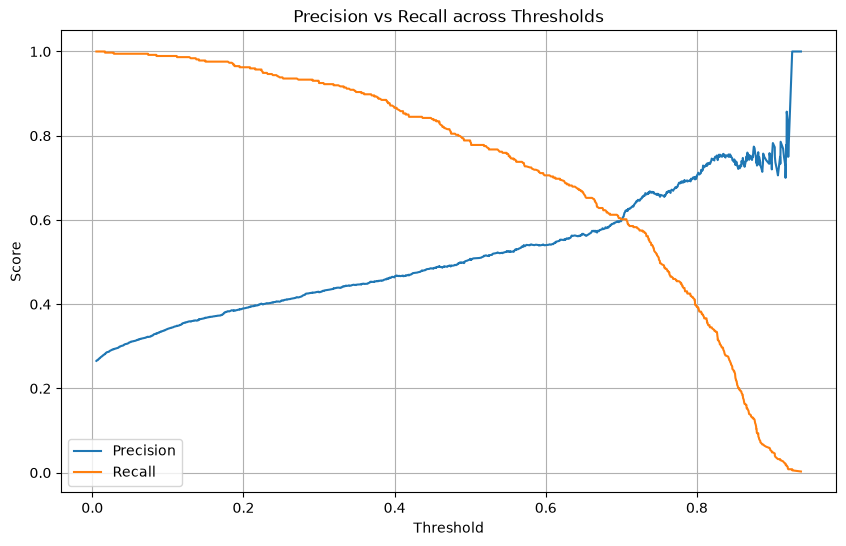

In [39]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall across Thresholds')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
from sklearn.metrics import f1_score
import numpy as np

f1_scores = []
threshold_range = np.arange(0.1,0.9,0.01)

for t in threshold_range:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_threshold = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best f1 score: {best_f1:.3f}")

Best threshold: 0.57
Best f1 score: 0.621


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [42]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from xgboost import XGBClassifier

scale_weight = (y_train == 0).sum() / (y_train == 1). sum()

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_weight,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1035
           1       0.52      0.66      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [44]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['Baseline LR', 'Balanced LR', 'Random Forest', 'XGBoost'],
    'Recall': [0.57, 0.79, 0.66, 0.66],
    'Precision': [0.66, 0.51, 0.56, 0.52],
    'F1': [0.61, 0.62, 0.60, 0.58]
})

results = results.sort_values('Recall', ascending=False)
print(results)

           Model  Recall  Precision    F1
1    Balanced LR    0.79       0.51  0.62
2  Random Forest    0.66       0.56  0.60
3        XGBoost    0.66       0.52  0.58
0    Baseline LR    0.57       0.66  0.61


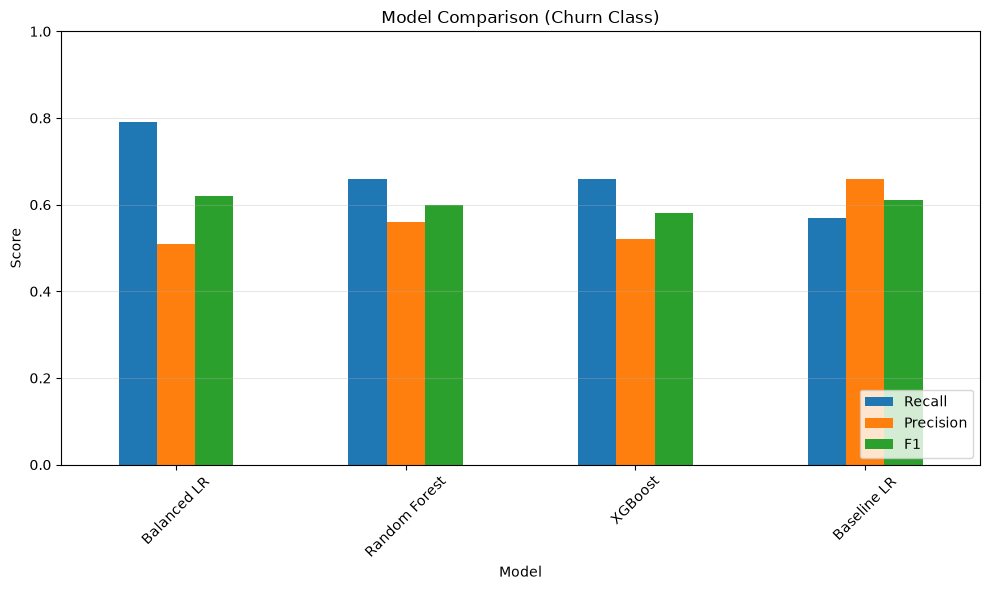

In [45]:
results_plot = results.set_index('Model')

results_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison (Churn Class)')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,20, None],
    'min_samples_split': [2,5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV recall:", rf_grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV recall: 0.7578595317725754


In [47]:
best_rf = rf_grid.best_estimator_
y_pred_best_rf  = best_rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [48]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=scale_weight, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV recall:", xgb_grid.best_score_)

Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV recall: 0.826086956521739


In [49]:
best_xgb = xgb_grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_best_xgb))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409



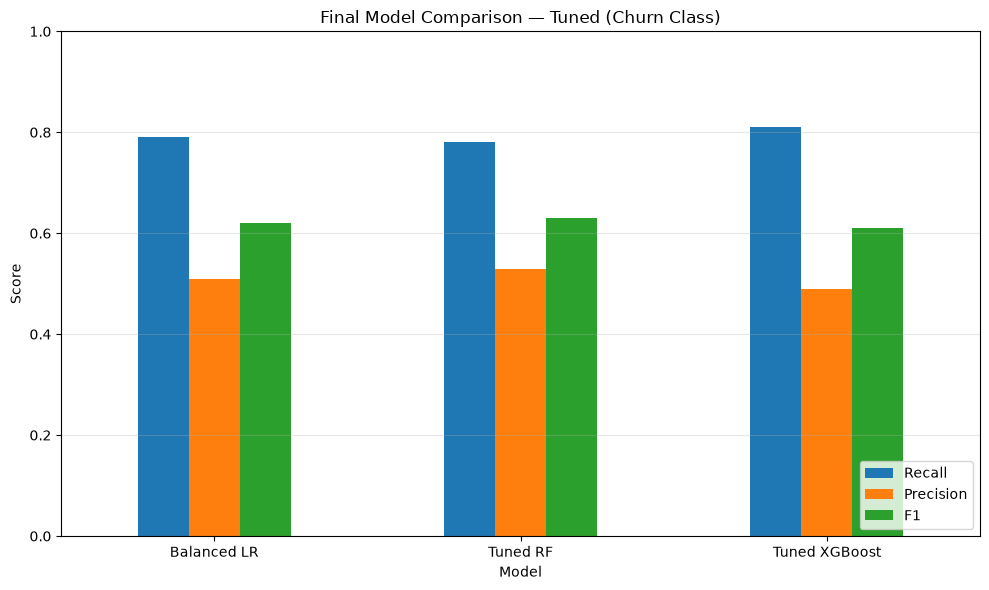

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

final_results = pd.DataFrame({
    'Model': ['Balanced LR', 'Tuned RF', 'Tuned XGBoost'],
    'Recall': [0.79, 0.78, 0.81],
    'Precision': [0.51, 0.53, 0.49],
    'F1': [0.62, 0.63, 0.61]
})

final_results = final_results.set_index('Model')

final_results.plot(kind='bar', figsize=(10, 6))
plt.title('Final Model Comparison — Tuned (Churn Class)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': Lr_balanced.coef_[0]
})

coefficients = coefficients.sort_values('Coefficient', ascending=False)
print(coefficients)

                                  Feature  Coefficient
11            InternetService_Fiber optic     0.808897
8                            TotalCharges     0.494748
24                    StreamingMovies_Yes     0.285948
22                        StreamingTV_Yes     0.273209
10                      MultipleLines_Yes     0.201165
28         PaymentMethod_Electronic check     0.188783
6                        PaperlessBilling     0.164703
18                   DeviceProtection_Yes     0.058287
1                           SeniorCitizen     0.056636
5                            PhoneService     0.024336
29             PaymentMethod_Mailed check     0.021529
0                                  gender     0.016094
2                                 Partner     0.008648
16                       OnlineBackup_Yes     0.004013
27  PaymentMethod_Credit card (automatic)    -0.000269
9          MultipleLines_No phone service    -0.024336
20                        TechSupport_Yes    -0.084193
15       O

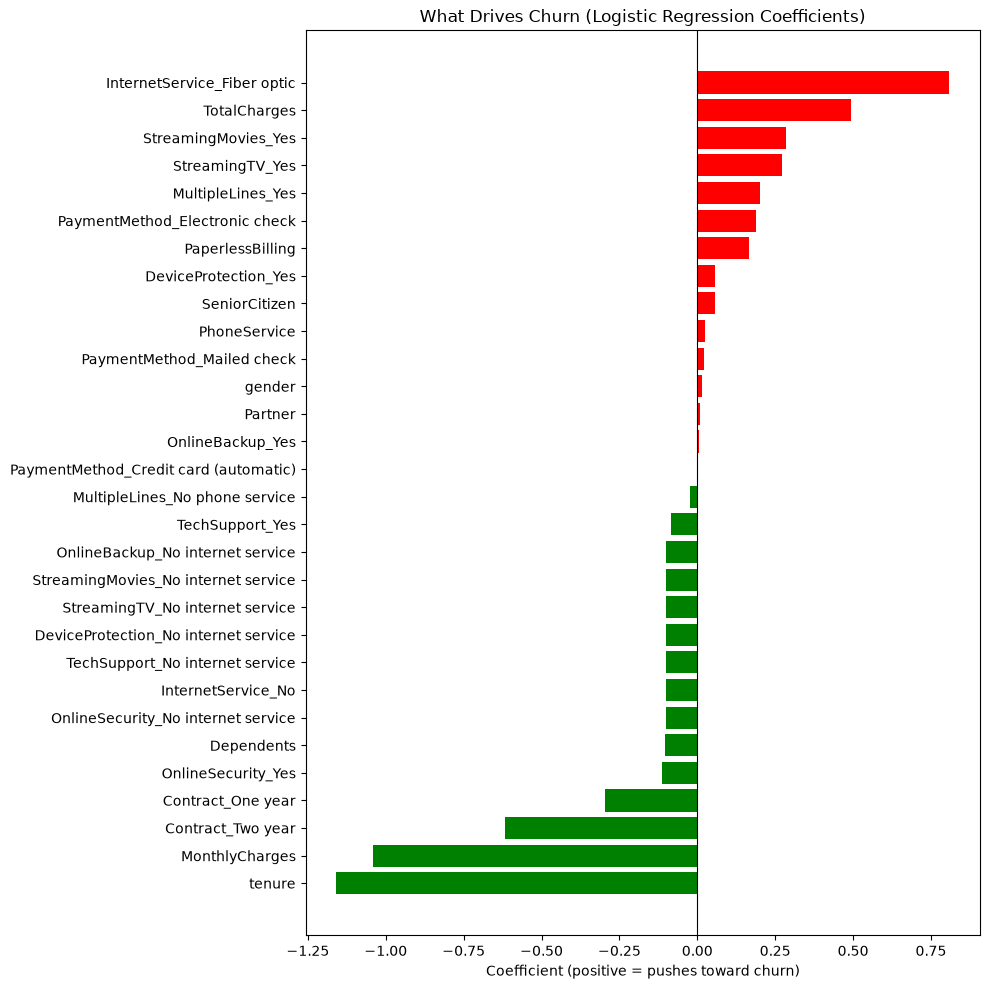

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': Lr_balanced.coef_[0]
}).sort_values('Coefficient')

plt.figure(figsize=(10, 10))
colors = ['green' if c < 0 else 'red' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.title('What Drives Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (positive = pushes toward churn)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed. Shape:", shap_values.shape)

c:\Users\hp\Documents\customer-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed. Shape: (1409, 30)


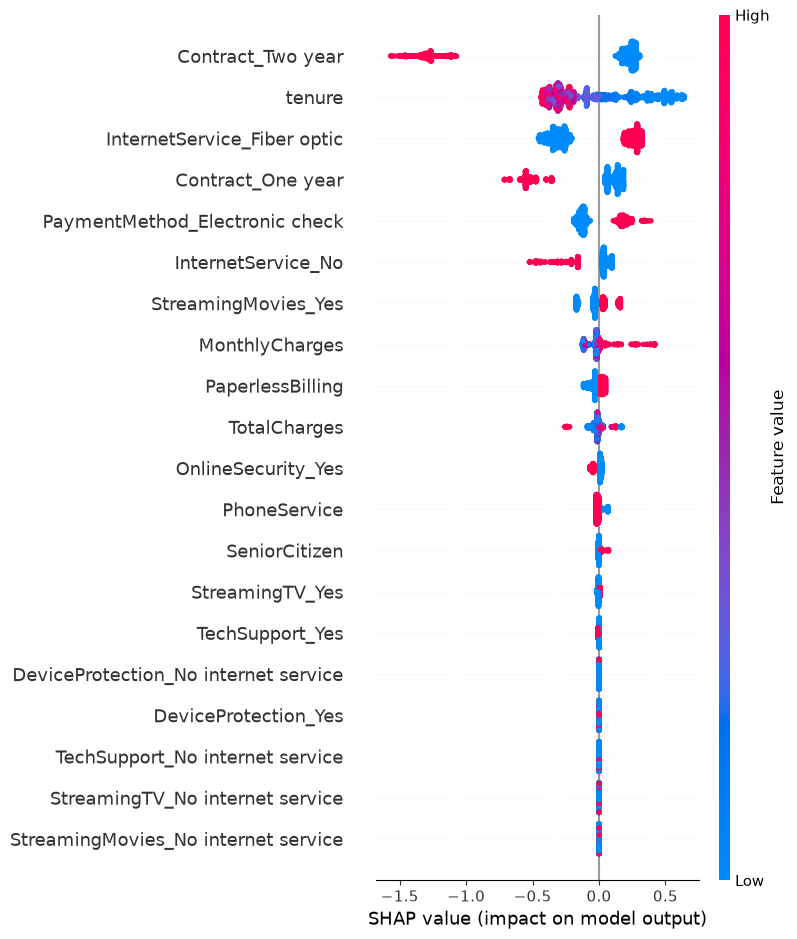

In [55]:
shap.summary_plot(shap_values, X_test)

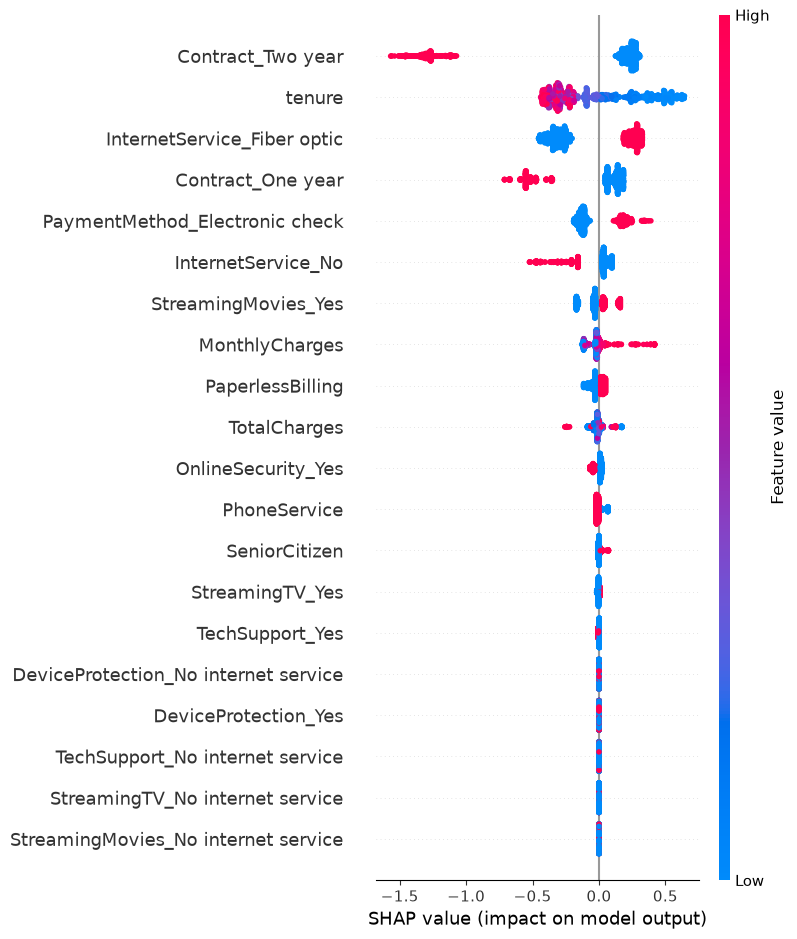

In [56]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

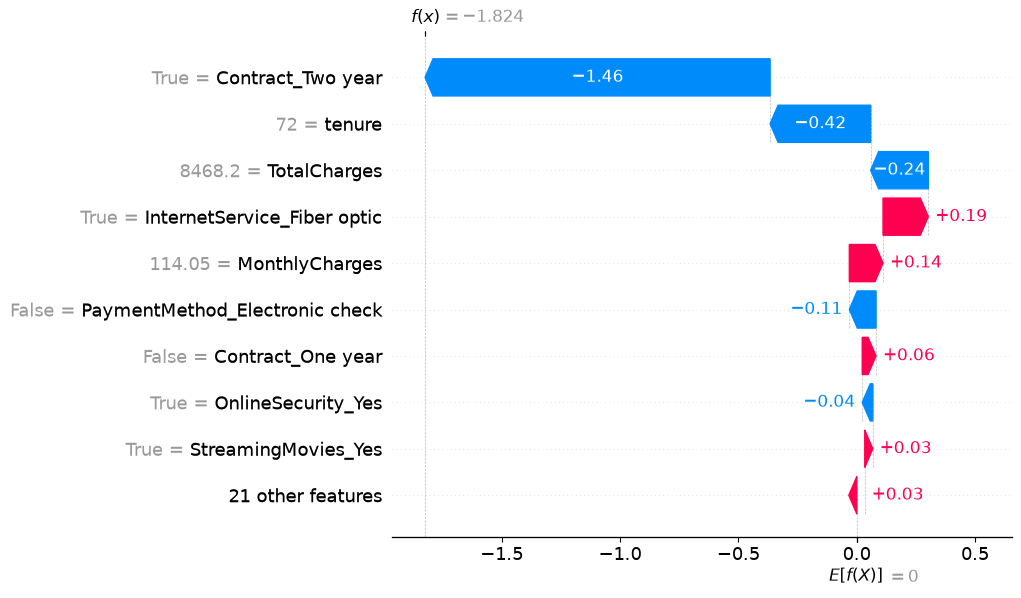

In [57]:
customer_index = 0

shap.plots.waterfall(shap.Explanation(
    values=shap_values[customer_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[customer_index],
    feature_names=X_test.columns.tolist()
))

In [58]:
import joblib

joblib.dump(Lr_balanced, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [59]:
print(list(X_test.iloc[0]))
print("Count:", len(X_test.iloc[0]))

[np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(72), np.int64(1), np.int64(1), np.float64(114.05), np.float64(8468.2), np.False_, np.True_, np.True_, np.False_, np.False_, np.True_, np.False_, np.True_, np.False_, np.True_, np.False_, np.True_, np.False_, np.True_, np.False_, np.True_, np.False_, np.True_, np.True_, np.False_, np.False_]
Count: 30


In [60]:
print("{\"features\": " + str([float(x) for x in X_test.iloc[0]]) + "}")

{"features": [1.0, 0.0, 1.0, 1.0, 72.0, 1.0, 1.0, 114.05, 8468.2, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0]}


In [61]:
import joblib
joblib.dump(Lr_balanced, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Re-saved with current sklearn version.")

Re-saved with current sklearn version.


In [62]:
import sklearn
print("Notebook sklearn:", sklearn.__version__)

Notebook sklearn: 1.9.0


In [63]:
from sklearn.linear_model import LogisticRegression
import joblib

# retrain fresh under current sklearn
Lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
Lr_balanced.fit(X_train_scaled, y_train)

# quick sanity check that predict_proba works HERE
test_proba = Lr_balanced.predict_proba(X_test_scaled)[0][1]
print("predict_proba works in notebook:", test_proba)

# save fresh
joblib.dump(Lr_balanced, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Freshly trained and saved.")

predict_proba works in notebook: 0.11837823033373074
Freshly trained and saved.
